In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

In [120]:
base_dir = os.getcwd()
data_path = os.path.join(base_dir, "..", "data", "hour.csv")

df = pd.read_csv(data_path)

In [121]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [122]:
df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [123]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [124]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [125]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [126]:
df1=df['cnt'].value_counts()
df1

cnt
5      260
6      236
4      231
3      224
2      208
      ... 
938      1
826      1
963      1
708      1
636      1
Name: count, Length: 869, dtype: int64

In [127]:
df.drop(['instant','dteday','casual','registered'], axis=1, inplace=True)

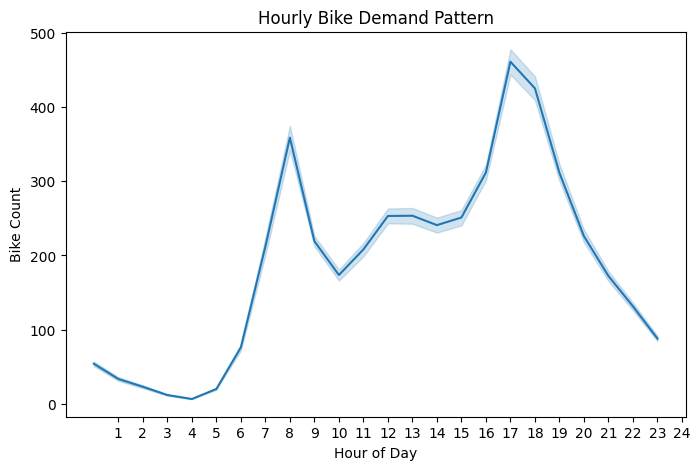

In [145]:
plt.figure(figsize=(8,5))
sns.lineplot(x="hr", y="cnt", data=df)
plt.title("Hourly Bike Demand Pattern")
plt.xlabel("Hour of Day")
plt.xticks(range(1, 25))
plt.ylabel("Bike Count")
plt.show()


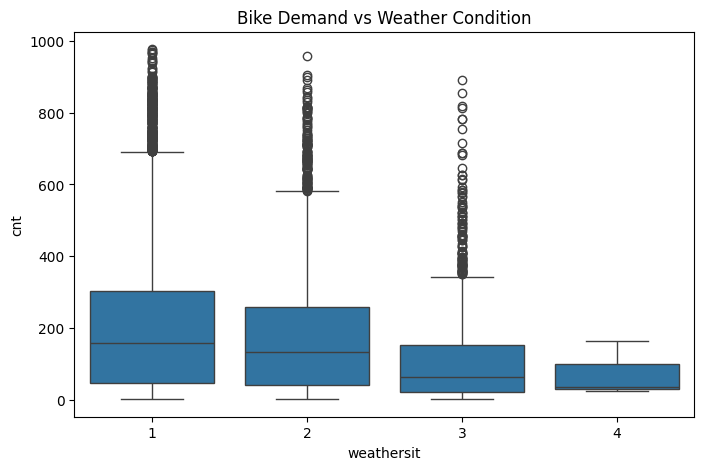

In [129]:
plt.figure(figsize=(8,5))
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Bike Demand vs Weather Condition")
plt.show()


In [130]:
x = df.drop('cnt', axis=1)
y = df['cnt']

In [131]:
x.shape


(17379, 12)

In [132]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [133]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [135]:
# LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train, y_train)
lr_pred=lr.predict(x_test)
lr_pred

array([450.04960343, 206.15173387,  57.43654037, ..., 376.72208275,
       265.63908384,  14.95080279], shape=(5214,))

In [136]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Decision Tree Regressor")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Decision Tree Regressor
MAE: 104.85283610636263
RMSE: 19360.109567445543
R2 Score: 0.38716067385039854


In [137]:
# DECISION TREE
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(criterion='squared_error')
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)
dt_pred

array([360.,  90.,  10., ..., 585., 268.,  76.], shape=(5214,))

In [138]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Regressor
MAE: 35.04181051016494
RMSE: 3679.4838895281932
R2 Score: 0.8835268767678623


In [139]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_pred

array([374.325,  99.57 ,  11.605, ..., 553.38 , 278.76 ,  74.885],
      shape=(5214,))

In [140]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Decision Tree Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Decision Tree Regressor
MAE: 25.306982380313073
RMSE: 1766.169157674493
R2 Score: 0.9440923661777468


In [141]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regression", "Random Forest Regression"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,104.852836,19360.109567,0.387161
1,Decision Tree Regression,35.041811,3679.483890,0.883527
2,Random Forest Regression,25.306982,1766.169158,0.944092


In [142]:
results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest Regression,25.306982,1766.169158,0.944092
1,Decision Tree Regression,35.041811,3679.483890,0.883527
0,Linear Regression,104.852836,19360.109567,0.387161


In [143]:
base_dir = os.getcwd()
MODEL_DIR = os.path.join(base_dir, "..", "model")

pickle.dump(lr, open(os.path.join(MODEL_DIR, "Linear_Regression_Model.pkl"), "wb"))
pickle.dump(dt, open(os.path.join(MODEL_DIR, "Decision_Tree_Model.pkl"), "wb"))
pickle.dump(rf, open(os.path.join(MODEL_DIR, "Random_Forest_Model.pkl"), "wb"))
pickle.dump(x.columns.tolist(), open(os.path.join(MODEL_DIR, "features.pkl"), "wb"))

print("All models and features saved successfully")

All models and features saved successfully
